# Fruktsamhet, befolkningstäthet och konjunktur
Kör alla celler uppifrån och ned. Kommunjämförelsen använder kvinnors summerade fruktsamhet och SCB:s faktiska riksserie. De nya blocken skapar ett gemensamt underlag med en rad per kommun och år. De utför ännu ingen regelutvinning eller avvikelsemodell.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Läs och skriv enbart i Dennis egen mapp.
kandidater = [Path.cwd(), Path.cwd() / "Dennis lek och bus"]
min_mapp = next((p for p in kandidater if (p / "FertilitetPerKommunNY.csv").is_file()), None)
assert min_mapp is not None, "Kör notebooken från din mapp eller projektroten."
data = min_mapp


In [2]:
fruktsamhet = pd.read_csv(
    data / "FertilitetPerKommunNY.csv",
    sep=";",
    na_values=[".."]
)

konjunktur = pd.read_csv(
    data / "konjunkturklockanNY.csv",
    sep=";",
    na_values=[".."]
)

tathet = pd.read_csv(
    data / "befolkningstathetNY.csv",
    encoding="utf-8-sig",
    dtype={"Kommunkod": "string"},
    na_values=[".."]
)
# SCB:s faktiska riksserie, inte ett medelvärde av kommunerna.
riket = pd.read_csv(data / "Fruktbarhet_riket.NYcsv", encoding="utf-8-sig", na_values=[".."])
riket = riket.loc[riket["kön"].eq("kvinnor")].rename(
    columns={"Summerad fruktsamhet, antal": "Värde"}
).copy()
assert riket["region"].eq("00 Riket").all()
assert not riket.duplicated("år").any()


In [3]:
display(fruktsamhet.head())
display(konjunktur.head())
display(tathet.head())

print("Fruktsamhet:", fruktsamhet.shape)
print("Konjunktur:", konjunktur.shape)
print("Befolkningstäthet:", tathet.shape)

,region,kön,tabellinnehåll,år,Värde
0,Upplands Väsby,män,Antal,2000,1.43
1,Upplands Väsby,män,Antal,2001,1.52
2,Upplands Väsby,män,Antal,2002,1.51
3,Upplands Väsby,män,Antal,2003,1.64
4,Upplands Väsby,män,Antal,2004,1.56


,indikator,tabellinnehåll,månad,Värde
0,BNP-indikator månad,Konjunkturläge,2000M01,-1.07
1,BNP-indikator månad,Konjunkturläge,2000M02,-0.84
2,BNP-indikator månad,Konjunkturläge,2000M03,-0.59
3,BNP-indikator månad,Konjunkturläge,2000M04,-0.29
4,BNP-indikator månad,Konjunkturläge,2000M05,0.01


,Kommunkod,Kommun,Kon,År,Befolkningstäthet (invånare per kvkm),Folkmängd
0,0114,Upplands Väsby,1+2,2000,498.6,37576.0
1,0114,Upplands Väsby,1+2,2001,497.9,37524.0
2,0114,Upplands Väsby,1+2,2002,496.8,37444.0
3,0114,Upplands Väsby,1+2,2003,496.2,37397.0
4,0114,Upplands Väsby,1+2,2004,497.8,37517.0


Fruktsamhet: (15080, 5)
Konjunktur: (8960, 4)
Befolkningstäthet: (7540, 6)


In [4]:
fruktsamhet = fruktsamhet.loc[
    fruktsamhet["kön"] == "kvinnor"
].copy()

fruktsamhet["Värde"] = pd.to_numeric(
    fruktsamhet["Värde"], errors="raise"
)

print("Antal kommuner:", fruktsamhet["region"].nunique())
print("Antal rader:", len(fruktsamhet))
print("Saknade värden:", fruktsamhet["Värde"].isna().sum())

assert not fruktsamhet.duplicated(["region", "år"]).any()

Antal kommuner: 290
Antal rader: 7540
Saknade värden: 204


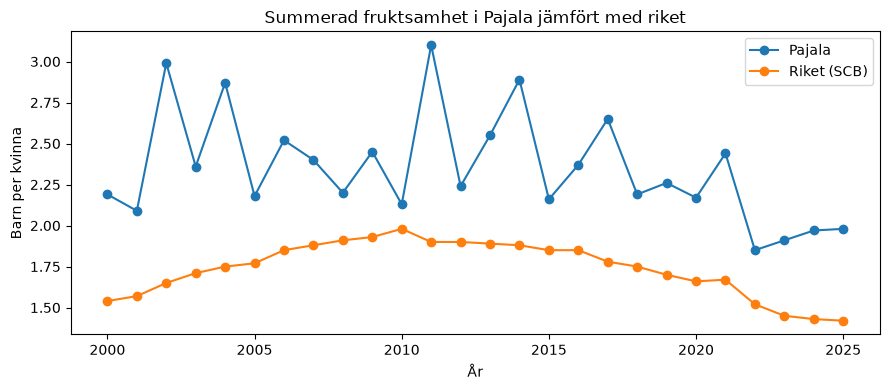

In [5]:
kommun = "Pajala"


urval = (
    fruktsamhet.loc[fruktsamhet["region"] == kommun]
    .sort_values("år")
)


ax = urval.plot(
    x="år",
    y="Värde",
    marker="o",
    label=kommun,
    figsize=(9, 4)
)

riket.plot(
    x="år",
    y="Värde",
    marker="o",
    label="Riket (SCB)",
    ax=ax
)

ax.set_title(f"Summerad fruktsamhet i {kommun} jämfört med riket")
ax.set_ylabel("Barn per kvinna")
ax.set_xlabel("År")
ax.legend()
plt.tight_layout()
plt.show()

## Koppla fruktsamhet till kommunkod och befolkningstäthet
Kommunfilen saknar kommunkod. Vi hämtar koden via en kontrollerad, entydig namnmatchning mot täthetsfilen. Därefter kopplas uppgifterna på kommunkod och år. Saknade fruktsamhetsvärden behålls.

In [6]:
for tabell, arkolumn in [(fruktsamhet, "år"), (riket, "år"), (tathet, "År")]:
    tabell[arkolumn] = pd.to_numeric(tabell[arkolumn], errors="raise").astype(int)
riket["Värde"] = pd.to_numeric(riket["Värde"], errors="raise")
for kolumn in ["Befolkningstäthet (invånare per kvkm)", "Folkmängd"]:
    tathet[kolumn] = pd.to_numeric(tathet[kolumn], errors="raise")
assert tathet["Kommunkod"].str.fullmatch(r"\d{4}").all()
assert not tathet.duplicated(["Kommunkod", "År"]).any()

namnnyckel = tathet[["Kommunkod", "Kommun"]].drop_duplicates().copy()
namnnyckel["namnnyckel"] = namnnyckel["Kommun"].str.strip().str.casefold()
assert not namnnyckel.duplicated("namnnyckel").any()
assert not namnnyckel.duplicated("Kommunkod").any()
kommun_data = fruktsamhet.rename(columns={"år": "ar", "Värde": "fruktsamhet"}).copy()
kommun_data["namnnyckel"] = kommun_data["region"].str.strip().str.casefold()
kommun_data = kommun_data.merge(namnnyckel, on="namnnyckel", how="left", validate="many_to_one")
assert kommun_data["Kommunkod"].notna().all(), "Något kommunnamn saknar matchning."
kommun_data = kommun_data[["Kommunkod", "Kommun", "ar", "fruktsamhet"]]

tathet_ar = tathet.rename(columns={"År": "ar", "Befolkningstäthet (invånare per kvkm)": "befolkningstathet", "Folkmängd": "folkmangd"})
kommun_data = kommun_data.merge(
    tathet_ar[["Kommunkod", "ar", "befolkningstathet", "folkmangd"]],
    on=["Kommunkod", "ar"], how="left", validate="one_to_one", indicator=True
)
assert kommun_data["_merge"].eq("both").all()
kommun_data = kommun_data.drop(columns="_merge")
kommun_data = kommun_data.merge(
    riket[["år", "Värde"]].rename(columns={"år": "ar", "Värde": "riket_fruktsamhet"}),
    on="ar", how="left", validate="many_to_one"
)
assert kommun_data["riket_fruktsamhet"].notna().all()
kommun_data["skillnad_mot_riket"] = kommun_data["fruktsamhet"] - kommun_data["riket_fruktsamhet"]

# Exakt föregående kalenderår, även om år saknas i en framtida fil.
foregaende = kommun_data[["Kommunkod", "ar", "fruktsamhet"]].copy()
foregaende["ar"] += 1
foregaende = foregaende.rename(columns={"fruktsamhet": "fruktsamhet_foregaende_ar"})
kommun_data = kommun_data.merge(foregaende, on=["Kommunkod", "ar"], how="left", validate="one_to_one")
kommun_data["forandring_fruktsamhet"] = kommun_data["fruktsamhet"] - kommun_data["fruktsamhet_foregaende_ar"]
display(kommun_data.head())


,Kommunkod,Kommun,ar,fruktsamhet,befolkningstathet,folkmangd,riket_fruktsamhet,skillnad_mot_riket,fruktsamhet_foregaende_ar,forandring_fruktsamhet
0,0114,Upplands Väsby,2000,1.54,498.6,37576.0,1.54,0.00,NaN,NaN
1,0114,Upplands Väsby,2001,1.59,497.9,37524.0,1.57,0.02,1.54,0.05
2,0114,Upplands Väsby,2002,1.65,496.8,37444.0,1.65,0.00,1.59,0.06
3,0114,Upplands Väsby,2003,1.81,496.2,37397.0,1.71,0.10,1.65,0.16
4,0114,Upplands Väsby,2004,1.69,497.8,37517.0,1.75,-0.06,1.81,-0.12


## Kommungrupper enligt SKR 2023
Huvudanalysen använder SKR:s tre huvudgrupper: A storstäder och storstadsnära kommuner, B större städer och kommuner nära större stad, C mindre städer/tätorter och landsbygdskommuner. Alla nio undergrupper följer med för mer detaljerad analys. A, B och C är kategorier, inte numeriska skalsteg.

Grupp C är inte liktydig med landsbygd. Om frågan specifikt gäller landsbygd behöver C8 och C9 granskas separat. Befolkningstätheten behålls som numerisk bakgrund och den tidigare medianindelningen som ett alternativ för känslighetsanalys.

Vi applicerar 2023 års klassificering på hela perioden. Det ger en retrospektiv gruppjämförelse, inte historiskt aktuella grupptillhörigheter. En strikt prognosutvärdering för år före 2023 kräver en klassificering som var tillgänglig före respektive prognostillfälle. Använd inte denna klassificering som om den vore känd redan 2004.


In [7]:
referensar = 2003
referens = tathet_ar.loc[tathet_ar["ar"].eq(referensar), ["Kommunkod", "befolkningstathet"]].copy()
assert not referens.duplicated("Kommunkod").any()
assert referens["befolkningstathet"].notna().all()
assert referens["befolkningstathet"].gt(0).all()
grans = referens["befolkningstathet"].median()
referens = referens.rename(columns={"befolkningstathet": "befolkningstathet_2003"})
referens["tathetsgrupp_2003"] = referens["befolkningstathet_2003"].map(
    lambda x: "Lägre täthet" if x < grans else "Högre täthet"
)
kommun_data = kommun_data.merge(referens, on="Kommunkod", how="left", validate="many_to_one")
assert kommun_data["tathetsgrupp_2003"].notna().all()
print(f"Gruppgräns: {grans:.1f} invånare/km² år {referensar}")
display(referens.groupby("tathetsgrupp_2003").size().rename("antal_kommuner"))

# SKR-filen är extraherad från bladet Bilaga1 Lista alla kommuner.
skr = pd.read_csv(data / "kommungrupper_SKR_2023.csv", encoding="utf-8-sig", dtype={"Kommunkod": "string"})
assert len(skr) == 290 and not skr.duplicated("Kommunkod").any()
assert skr["skr_huvudgrupp_kod"].isin(["A", "B", "C"]).all()
kommun_data = kommun_data.merge(skr, on="Kommunkod", how="left", validate="many_to_one", indicator=True)
assert kommun_data["_merge"].eq("both").all(), "Någon kommun saknar SKR-grupp."
kommun_data = kommun_data.drop(columns="_merge")
assert kommun_data["Kommun"].str.strip().str.casefold().eq(kommun_data["Kommun_SKR"].str.strip().str.casefold()).all()
kommun_data["kommuntyp"] = kommun_data["skr_huvudgrupp_kod"]
kommun_data["skr_referensar"] = 2023
print("Huvudgrupper för analysen: A, B, C enligt SKR 2023")
display(skr.groupby(["skr_huvudgrupp_kod", "skr_huvudgrupp"]).size().rename("antal_kommuner"))


Gruppgräns: 26.4 invånare/km² år 2003


tathetsgrupp_2003
Högre täthet    146
Lägre täthet    144
Name: antal_kommuner, dtype: int64

Huvudgrupper för analysen: A, B, C enligt SKR 2023


skr_huvudgrupp_kod  skr_huvudgrupp                               
A                   Storstäder och storstadsnära kommuner             46
B                   Större städer och kommuner nära större stad      110
C                   Mindre städer/tätorter och landsbygdskommuner    134
Name: antal_kommuner, dtype: int64

## Konjunktur per år och tidsfördröjning
Vi använder konjunkturläge för BNP-indikator månad, hushållens konsumtion och sysselsättning. Årsmedel beräknas endast med tolv observerade månader. Lagg 1 betyder att fruktsamhet år t jämförs med konjunktur år t−1. Konjunkturen är gemensam för alla kommuner. Värdena är standardiserade konjunkturlägen, inte tillväxttal eller sysselsättningsgrader.

In [8]:
indikatorer = {"BNP-indikator månad": "bnp", "Hushållens konsumtion": "konsumtion", "Sysselsättning": "sysselsattning"}
ekonomi = konjunktur.loc[
    konjunktur["tabellinnehåll"].eq("Konjunkturläge") & konjunktur["indikator"].isin(indikatorer)
].copy()
ekonomi["datum"] = pd.to_datetime(ekonomi["månad"], format="%YM%m", errors="raise")
ekonomi["ar"] = ekonomi["datum"].dt.year
ekonomi["Värde"] = pd.to_numeric(ekonomi["Värde"], errors="raise")
assert not ekonomi.duplicated(["indikator", "datum"]).any()
ekonomi = ekonomi.loc[ekonomi["ar"].between(2000, 2025)]
arskontroll = ekonomi.groupby(["ar", "indikator"])["Värde"].agg(medel="mean", antal_manader="count").reset_index()
arskontroll.loc[arskontroll["antal_manader"].ne(12), "medel"] = float("nan")
konjunktur_ar = arskontroll.pivot(index="ar", columns="indikator", values="medel").rename(columns=indikatorer).reset_index()
konjunktur_ar.columns.name = None

analysdata = kommun_data.copy()
for lagg in [0, 1, 2]:
    laggad = konjunktur_ar.copy()
    laggad["ar"] += lagg
    laggad = laggad.rename(columns={namn: f"{namn}_lag{lagg}" for namn in indikatorer.values()})
    analysdata = analysdata.merge(laggad, on="ar", how="left", validate="many_to_one")
analysdata = analysdata.loc[analysdata["ar"].between(2004, 2025)].sort_values(["Kommunkod", "ar"]).reset_index(drop=True)
assert not analysdata.duplicated(["Kommunkod", "ar"]).any()
display(arskontroll.loc[arskontroll["antal_manader"].ne(12)])
display(analysdata.head())
print(f"Analystabell: {len(analysdata)} rader, {analysdata['Kommunkod'].nunique()} kommuner")


,ar,indikator,medel,antal_manader
2,2000,Sysselsättning,NaN,0


,Kommunkod,Kommun,ar,fruktsamhet,befolkningstathet,folkmangd,riket_fruktsamhet,skillnad_mot_riket,fruktsamhet_foregaende_ar,forandring_fruktsamhet,...,skr_referensar,bnp_lag0,konsumtion_lag0,sysselsattning_lag0,bnp_lag1,konsumtion_lag1,sysselsattning_lag1,bnp_lag2,konsumtion_lag2,sysselsattning_lag2
0,0114,Upplands Väsby,2004,1.69,497.8,37517.0,1.75,-0.06,1.81,-0.12,...,2023,-0.259167,-0.929167,-0.995833,-0.925000,-0.553333,-0.116667,-0.423333,-0.244167,0.509167
1,0114,Upplands Väsby,2005,1.81,499.2,37624.0,1.77,0.04,1.69,0.12,...,2023,0.215000,-0.122500,-1.293333,-0.259167,-0.929167,-0.995833,-0.925000,-0.553333,-0.116667
2,0114,Upplands Väsby,2006,1.80,502.2,37848.0,1.85,-0.05,1.81,-0.01,...,2023,1.423333,0.857500,-0.198333,0.215000,-0.122500,-1.293333,-0.259167,-0.929167,-0.995833
3,0114,Upplands Väsby,2007,1.93,504.9,38055.0,1.88,0.05,1.80,0.13,...,2023,2.357500,1.937500,1.605833,1.423333,0.857500,-0.198333,0.215000,-0.122500,-1.293333
4,0114,Upplands Väsby,2008,1.79,507.5,38248.0,1.91,-0.12,1.93,-0.14,...,2023,1.065833,0.487500,1.950833,2.357500,1.937500,1.605833,1.423333,0.857500,-0.198333


Analystabell: 6380 rader, 290 kommuner


## Bortfall och kommungrupper jämfört med riket
Grupplinjerna är ovägda medel av tillgängliga kommunvärden. De beskriver en genomsnittlig kommun i gruppen, inte ett befolkningsvägt fruktsamhetsmått. Rikets linje är SCB:s separata riksserie. Saknade observationer kan ändra vilka kommuner som ingår ett visst år.

Kompletta rader för förändring och tre indikatorer med lagg 1: 6153


,kommuner,kommun_ar,observerad_fruktsamhet,saknade_fruktsamhet,bortfall_procent
kommuntyp,,,,,
A,46,1012,1012,0,0.00
B,110,2420,2383,37,1.53
C,134,2948,2800,148,5.02


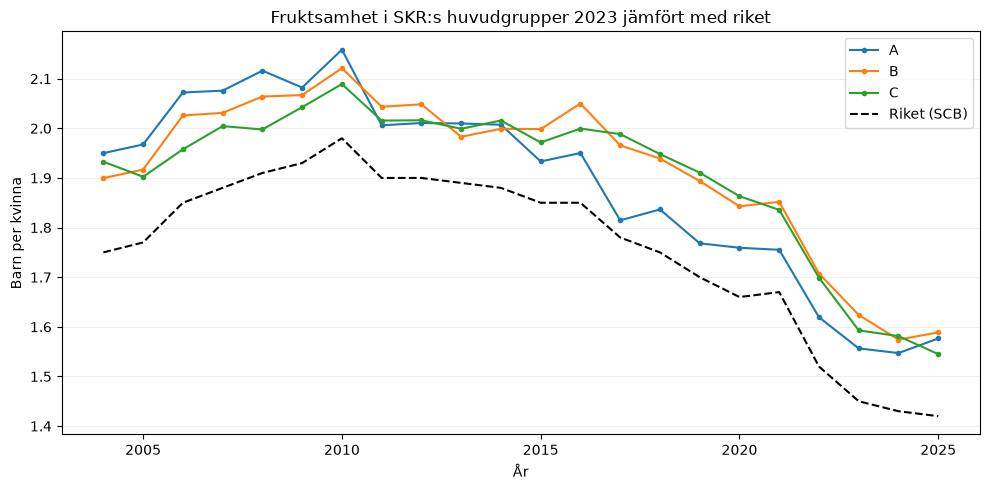

In [9]:
kontroll = analysdata.groupby("kommuntyp").agg(
    kommuner=("Kommunkod", "nunique"), kommun_ar=("ar", "size"),
    observerad_fruktsamhet=("fruktsamhet", "count")
)
kontroll["saknade_fruktsamhet"] = kontroll["kommun_ar"] - kontroll["observerad_fruktsamhet"]
kontroll["bortfall_procent"] = 100 * kontroll["saknade_fruktsamhet"] / kontroll["kommun_ar"]
krav = ["forandring_fruktsamhet", "bnp_lag1", "konsumtion_lag1", "sysselsattning_lag1"]
print("Kompletta rader för förändring och tre indikatorer med lagg 1:", analysdata[krav].notna().all(axis=1).sum())
display(kontroll.round(2))

gruppmedel = analysdata.groupby(["ar", "kommuntyp"])["fruktsamhet"].mean().unstack()
ax = gruppmedel.plot(figsize=(10, 5), marker="o", markersize=3)
riksurval = riket.loc[riket["år"].between(2004, 2025)].sort_values("år")
ax.plot(riksurval["år"], riksurval["Värde"], color="black", linestyle="--", label="Riket (SCB)")
ax.set_title("Fruktsamhet i SKR:s huvudgrupper 2023 jämfört med riket")
ax.set_xlabel("År")
ax.set_ylabel("Barn per kvinna")
ax.grid(axis="y", alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()


## Spara det gemensamma underlaget
När du kör nästa cell sparas analystabellen och datakontrollen i `Dennis lek och bus/resultat`. Originaldata ändras inte. Körningen ersätter tidigare exporter med samma namn. Kommunkod ska läsas som text vid nästa import.

Nästa analyssteg är att fastställa en kursrelevant regelalgoritm, kategorisera variabler på utvecklingsperioden och utvärdera regler över tid. Diagrammen här visar ingen konjunktureffekt. Täthetsgrupper, geografiska gränsändringar och det större bortfallet bland små kommuner måste beaktas. Framtida år har redan visats i diagram och ska inte beskrivas som helt osedda testdata.

In [10]:
resultatmapp = min_mapp / "resultat_SKR_2023"
resultatmapp.mkdir(exist_ok=True)
analysdata.to_csv(resultatmapp / "analysunderlag_2004_2025.csv", index=False, encoding="utf-8-sig")
kontroll.to_csv(resultatmapp / "datakontroll_per_grupp.csv", encoding="utf-8-sig")
arskontroll.to_csv(resultatmapp / "konjunktur_datatackning.csv", index=False, encoding="utf-8-sig")
print(f"Sparat i {resultatmapp}")


Sparat i /Users/dennis/DataMining-project/Dennis lek och bus/resultat_SKR_2023


## Granska NY-filerna inför ARM
Originalfilerna bevaras. Filtrering betyder här ett separat analysurval. Män tas bort från fruktsamhetsanalysen eftersom utfallet gäller kvinnor. Tätheten avser däremot hela befolkningen och ska behållas. Riksserien är en referens, inte en extra kommuntransaktion.

Vi granskar alla 14 konjunkturindikatorer innan ett slutligt indikatorurval beslutas. Saknade uppgifter får inte bli noll eller kategorin oförändrat. Ovanliga men möjliga fruktsamhetsvärden tas inte bort automatiskt.

In [11]:
# Kontrollera råfilernas nycklar och bortfall innan nya urval görs.
kommun_raw = pd.read_csv(data / "FertilitetPerKommunNY.csv", sep=";", na_values=[".."])
konj_raw = pd.read_csv(data / "konjunkturklockanNY.csv", sep=";", na_values=[".."])
riket_kvinnor = pd.read_csv(data / "Fruktbarhet_riket_kvinnorNY.csv", header=None,
    names=["region", "kön", "år", "Värde"], na_values=[".."])
pd.testing.assert_series_equal(
    riket.set_index("år")["Värde"].sort_index(),
    riket_kvinnor.set_index("år")["Värde"].sort_index(), check_names=False, check_dtype=False
)
assert not kommun_raw.duplicated(["region", "kön", "år"]).any()
assert not konj_raw.duplicated(["indikator", "tabellinnehåll", "månad"]).any()
assert not tathet.duplicated(["Kommunkod", "År"]).any()
print("Unika nycklar kontrollerade. De två riksfilerna ger samma kvinnoserie.")
display(kommun_raw.groupby("kön")["Värde"].agg(rader="size", observerade="count"))

# Alla indikatorer och båda måtten granskas, även de som inte valts ovan.
konj_raw["ar"] = pd.to_datetime(konj_raw["månad"], format="%YM%m").dt.year
konj_raw["Värde"] = pd.to_numeric(konj_raw["Värde"], errors="raise")
konj_tackning = konj_raw.groupby(["indikator", "tabellinnehåll", "ar"])["Värde"].agg(
    rader="size", observerade="count"
).reset_index()
konj_tackning["saknade"] = konj_tackning["rader"] - konj_tackning["observerade"]
display(konj_tackning.loc[konj_tackning["observerade"].ne(12)])

# Flagga orimliga eller geografiskt svårtolkade värden, utan att radera dem.
geografiska_flaggor = tathet.loc[
    tathet["Befolkningstäthet (invånare per kvkm)"].le(0)
    | tathet["Folkmängd"].le(0)
    | (tathet["Kommunkod"].eq("0330") & tathet["År"].lt(2003))
].copy()
display(geografiska_flaggor)
print("Fruktsamhet kvinnor, min/max:", fruktsamhet["Värde"].min(), fruktsamhet["Värde"].max())


Unika nycklar kontrollerade. De två riksfilerna ger samma kvinnoserie.


,rader,observerade
kön,,
kvinnor,7540,7336
män,7540,7330


,indikator,tabellinnehåll,ar,rader,observerade,saknade
0,Arbetade timmar,Förändring från föregående period,2000,12,0,12
1,Arbetade timmar,Förändring från föregående period,2001,12,11,1
26,Arbetade timmar,Förändring från föregående period,2026,8,7,1
27,Arbetade timmar,Konjunkturläge,2000,12,0,12
53,Arbetade timmar,Konjunkturläge,2026,8,7,1
54,BNP kvartal,Förändring från föregående period,2000,12,9,3
80,BNP kvartal,Förändring från föregående period,2026,8,6,2
107,BNP kvartal,Konjunkturläge,2026,8,6,2
108,BNP-indikator månad,Förändring från föregående period,2000,12,11,1
134,BNP-indikator månad,Förändring från föregående period,2026,8,7,1


,Kommunkod,Kommun,Kon,År,Befolkningstäthet (invånare per kvkm),Folkmängd
728,0330,Knivsta,1+2,2000,0.0,0.0
729,0330,Knivsta,1+2,2001,0.0,0.0
730,0330,Knivsta,1+2,2002,44.4,12586.0


Fruktsamhet kvinnor, min/max: 0.96 3.15


## Separat ARM-urval och bortfallslogg
Startförslaget är utfallsår 2004–2025 med föregående års konsumtion, sysselsättning och BNP-indikator. Åren före 2004 behålls som historik för referensår och tidsfördröjningar. År 2026 i konjunkturfilen ingår inte eftersom fruktsamhetsdata slutar 2025.

Bara rader med de variabler som denna analys behöver tas med i ARM-urvalet. Övriga rader sparas med förklaring. Ett annat indikatorurval kan ge ett annat bortfall. Radera alltså inte rader som saknar någon av samtliga 14 indikatorer som generell regel.

Ingen kommun tas bort enbart för låg befolkning eller ett extremvärde. Geografiska förändringar, bland annat Knivsta/Uppsala och Lidingö/Vaxholm, kräver en separat känslighetskontroll. Att börja 2004 löser inte alla gränsändringar.

In [12]:
arm_krav = ["forandring_fruktsamhet", "kommuntyp", "konsumtion_lag1", "sysselsattning_lag1", "bnp_lag1"]
arm_mask = analysdata[arm_krav].notna().all(axis=1)
arm_underlag = analysdata.loc[arm_mask].copy()
arm_bortfall = analysdata.loc[~arm_mask].copy()
arm_bortfall["saknade_variabler"] = arm_bortfall[arm_krav].apply(
    lambda rad: ", ".join(rad.index[rad.isna()]), axis=1
)
assert len(arm_underlag) + len(arm_bortfall) == len(analysdata)
assert not arm_underlag.duplicated(["Kommunkod", "ar"]).any()
print(f"Hela analystabellen: {len(analysdata)} kommun–år")
print(f"ARM-starturval: {len(arm_underlag)}; exkluderade rader: {len(arm_bortfall)}")
display(arm_bortfall.groupby(["kommuntyp", "saknade_variabler"]).size().rename("antal_rader"))

resultatmapp = min_mapp / "resultat_SKR_2023"
resultatmapp.mkdir(exist_ok=True)
arm_underlag.to_csv(resultatmapp / "arm_underlag_lag1.csv", index=False, encoding="utf-8-sig")
arm_bortfall.to_csv(resultatmapp / "arm_bortfall_lag1.csv", index=False, encoding="utf-8-sig")
konj_tackning.to_csv(resultatmapp / "konjunktur_tackning_alla_indikatorer.csv", index=False, encoding="utf-8-sig")
geografiska_flaggor.to_csv(resultatmapp / "geografiska_flaggor.csv", index=False, encoding="utf-8-sig")


Hela analystabellen: 6380 kommun–år
ARM-starturval: 6153; exkluderade rader: 227


kommuntyp  saknade_variabler     
B          forandring_fruktsamhet     44
C          forandring_fruktsamhet    183
Name: antal_rader, dtype: int64

## ARM med SKR:s huvudgrupper
Denna första körning använder tre indikatorer med ett års lagg: hushållens konsumtion, BNP-indikator månad och sysselsättning. Varje kommun–år är en transaktion med tre ekonomiska kategorier och ett utfall (ökning, minskning eller oförändrad fruktsamhet). Grupperna A, B och C analyseras separat med samma inställningar.

Vi använder en kort implementation av Apriori med högst tre objekt per frekvent mängd. Den tillåter regler med en eller två ekonomiska kategorier till vänster och ett fruktsamhetsutfall till höger. Ingen extra installation utöver notebookens befintliga bibliotek behövs. Support och lift beräknas inom respektive grupp.

Inställningarna är förvalda startvärden, inte optimerade värden: support minst 5 %, confidence minst 60 %, lift minst 1,10 och stöd i minst tre olika träningsår för både villkor och hela regeln. Högst fem regler per grupp behålls utifrån träningsresultaten. Om ingen regel uppfyller kraven accepteras det resultatet. Inga gränser justeras med hjälp av senare år.

Träning: 2004–2015. Validering: 2016–2019. Senare utvärdering: 2020–2025. Valideringen rapporteras separat utan efterföljande parameterurval i denna första körning. Tidigare diagram har redan visat hela perioden. Med SKR:s indelning från 2023 och reviderade ekonomiska tidsserier är detta en retrospektiv utvärdering, inte ett verifierat realtidsprognostest.


In [13]:
# Inställningar bestäms före utvärderingen. Ändra inte efter att ha sett testresultatet.
from itertools import combinations
import numpy as np

ARM_FEATURES = ['konsumtion_lag1', 'sysselsattning_lag1', 'bnp_lag1']
MIN_SUPPORT = 0.05  # inom respektive SKR-grupp
MIN_CONFIDENCE = 0.60
MIN_LIFT = 1.10
MIN_VILLKORSAR = 3
MIN_REGELAR = 3
MAX_REGLER_PER_GRUPP = 5

arm = arm_underlag.copy()
assert arm[ARM_FEATURES + ['forandring_fruktsamhet', 'kommuntyp']].notna().all().all()
# Runda till ursprungsmåttets två decimaler så att flyttalsfel inte skapar förändringar.
forandring = arm['forandring_fruktsamhet'].round(2)
arm['utfall'] = np.select([forandring.lt(0), forandring.gt(0)], ['minskning', 'okning'], default='oforandrat')
for feature in ARM_FEATURES:
    arm[feature + '_kategori'] = np.where(arm[feature].lt(0), 'under_trend', 'vid_eller_over_trend')
arm['period'] = np.select([arm['ar'].le(2015), arm['ar'].le(2019)], ['traning', 'validering'], default='senare_ar')
arm = arm.reset_index(drop=True)
items = [f'{f}={v}' for f in ARM_FEATURES for v in ['under_trend', 'vid_eller_over_trend']]
items += [f'utfall={v}' for v in ['minskning', 'oforandrat', 'okning']]
transaktioner = pd.DataFrame(False, index=arm.index, columns=items)
for item in items:
    variable, value = item.split('=')
    transaktioner[item] = arm['utfall'].eq(value) if variable == 'utfall' else arm[variable + '_kategori'].eq(value)
assert transaktioner.sum(axis=1).eq(4).all()
display(arm.groupby(['period', 'kommuntyp']).agg(rader=('ar','size'), ar=('ar','nunique')))



rader  ar
period     kommuntyp           
senare_ar  A            276   6
           B            644   6
           C            739   6
traning    A            552  12
           B           1300  12
           C           1519  12
validering A            184   4
           B            432   4
           C            507   4

## Hitta frekventa mängder och riktade regler
Confidence visar hur ofta utfallet inträffar när villkoren gäller. Lift jämför med utfallets basfrekvens inom samma kommungrupp. Antal olika år måste granskas tillsammans med antalet kommun–år, eftersom alla kommuner delar samma konjunkturvärde ett visst år.

In [14]:
# Apriori: bygg större frekventa mängder enbart när alla delmängder är frekventa.
# Högst tre objekt ger högst två konjunkturvillkor och ett utfall per regel.
def apriori_begransad(tabell, min_support=0.05, max_len=3):
    if tabell.empty:
        return {}
    supports = {}
    level = set()
    for col in tabell.columns:
        support = float(tabell[col].mean())
        if support >= min_support:
            itemset = frozenset([col])
            supports[itemset] = support
            level.add(itemset)
    for size in range(2, max_len + 1):
        candidates = set()
        for a, b in combinations(level, 2):
            candidate = a | b
            if len(candidate) != size:
                continue
            variables = [x.split('=')[0] for x in candidate]
            if len(set(variables)) != size:  # motsägande kategorier får inte kombineras
                continue
            if all(frozenset(sub) in level for sub in combinations(candidate, size - 1)):
                candidates.add(candidate)
        next_level = set()
        for candidate in sorted(candidates, key=lambda x: tuple(sorted(x))):
            support = float(tabell[list(candidate)].all(axis=1).mean())
            if support >= min_support:
                supports[candidate] = support
                next_level.add(candidate)
        level = next_level
        if not level:
            break
    return supports


def villkorsmask(tabell, villkor):
    return tabell[list(villkor)].all(axis=1)


def regelmatt(index, villkor, utfall):
    t = transaktioner.loc[index]
    a = villkorsmask(t, villkor)
    c = t['utfall=' + utfall]
    both = a & c
    confidence = float(c[a].mean()) if a.any() else np.nan
    base = float(c.mean()) if len(t) else np.nan
    return dict(antal_rader=len(t), villkor_rader=int(a.sum()), regel_rader=int(both.sum()),
        villkor_ar=arm.loc[t.index[a], 'ar'].nunique(), regel_ar=arm.loc[t.index[both], 'ar'].nunique(),
        support=float(both.mean()) if len(t) else np.nan,
        confidence=confidence, basfrekvens=base,
        lift=confidence/base if base > 0 else np.nan,
        skillnad_mot_bas=confidence-base)

regelposter = []
for group in ['A', 'B', 'C']:
    idx = arm.index[arm['kommuntyp'].eq(group) & arm['period'].eq('traning')]
    frequent = apriori_begransad(transaktioner.loc[idx], MIN_SUPPORT)
    for itemset in frequent:
        outcomes = [x for x in itemset if x.startswith('utfall=')]
        if len(outcomes) != 1 or len(itemset) < 2:
            continue
        antecedent = tuple(sorted(itemset - {outcomes[0]}))
        outcome = outcomes[0].split('=')[1]
        metrics = regelmatt(idx, antecedent, outcome)
        regelposter.append(dict(kommuntyp=group, villkor=antecedent, utfall=outcome, **metrics))
regler = pd.DataFrame(regelposter)
regler['godkand_traning'] = (
    regler['confidence'].ge(MIN_CONFIDENCE) & regler['lift'].ge(MIN_LIFT)
    & regler['villkor_ar'].ge(MIN_VILLKORSAR) & regler['regel_ar'].ge(MIN_REGELAR)
)
# Fast rangordning från träning; används även vid motstridiga prognosregler.
regler['villkor_text'] = regler['villkor'].map(lambda x: ' & '.join(x))
regler = regler.sort_values(['kommuntyp','lift','confidence','support','villkor_text','utfall'],
    ascending=[True,False,False,False,True,True])
valda_regler = regler.loc[regler['godkand_traning']].groupby('kommuntyp', sort=False).head(MAX_REGLER_PER_GRUPP).copy()
print('Kandidatregler:', len(regler), 'Valda regler:', len(valda_regler))
display(valda_regler[['kommuntyp','villkor_text','utfall','confidence','basfrekvens','lift','support','villkor_ar','regel_ar']])



Kandidatregler: 84 Valda regler: 1


,kommuntyp,villkor_text,utfall,confidence,basfrekvens,lift,support,villkor_ar,regel_ar
21,A,bnp_lag1=vid_eller_over_trend & sysselsattning...,okning,0.630435,0.496377,1.270073,0.157609,3,3


## Jämför regler och utvärdera en enkel regelmodell
Alla valda ekonomiska villkor utvärderas i alla tre grupper. En hög confidence i träning räcker inte. Vid prognos väljs första matchande regel i träningsrangordningen. Om ingen matchar används gruppens vanligaste träningsutfall. Träffsäkerheten jämförs med denna baslinje på exakt samma observationer. Regeltäckning anger andelen observationer där minst en regel matchar.

In [15]:
# Jämför samma ekonomiska villkor och utfall i ALLA grupper, inte bara gruppen
# där regeln hittades. Inga nya regler väljs utifrån senare år.
jamforelseposter = []
rule_keys = sorted(set(zip(valda_regler['villkor'], valda_regler['utfall'])))
for antecedent, outcome in rule_keys:
    for group in ['A', 'B', 'C']:
        for period in ['traning','validering','senare_ar']:
            idx = arm.index[arm['kommuntyp'].eq(group) & arm['period'].eq(period)]
            jamforelseposter.append(dict(kommuntyp=group, period=period,
                villkor_text=' & '.join(antecedent), utfall=outcome, **regelmatt(idx, antecedent, outcome)))
regeljamforelse = pd.DataFrame(jamforelseposter)

# En enkel regelklassificerare: första matchande regel i träningsrangordningen.
# Om ingen matchar används vanligaste träningsutfallet inom kommungruppen.
prognoser = []
for group in ['A','B','C']:
    train = arm.loc[arm['kommuntyp'].eq(group) & arm['period'].eq('traning')]
    baseline = train['utfall'].mode().sort_values().iloc[0]
    chosen = valda_regler.loc[valda_regler['kommuntyp'].eq(group)]
    for period in ['validering','senare_ar']:
        idx = arm.index[arm['kommuntyp'].eq(group) & arm['period'].eq(period)]
        pred = pd.Series(baseline, index=idx)
        used = pd.Series(False,index=idx)
        for _, rule in chosen.iterrows():
            hits = villkorsmask(transaktioner.loc[idx],rule['villkor']) & ~used
            pred.loc[hits] = rule['utfall']
            used |= hits
        for i in idx:
            prognoser.append(dict(Kommunkod=arm.at[i,'Kommunkod'],ar=int(arm.at[i,'ar']),kommuntyp=group,
                period=period,utfall=arm.at[i,'utfall'],prognos=pred.at[i],baslinje=baseline,regel_match=bool(used.at[i])))
prognoser = pd.DataFrame(prognoser)
prognoser['ratt'] = prognoser['utfall'].eq(prognoser['prognos'])
prognoser['baslinje_ratt'] = prognoser['utfall'].eq(prognoser['baslinje'])
utvardering = prognoser.groupby(['kommuntyp','period']).agg(
    rader=('ar','size'),ar=('ar','nunique'),traffsakerhet=('ratt','mean'),
    baslinje_traffsakerhet=('baslinje_ratt','mean'),regeltackning=('regel_match','mean')).reset_index()
utvardering['skillnad_mot_baslinje'] = utvardering['traffsakerhet'] - utvardering['baslinje_traffsakerhet']
utvardering_ar = prognoser.groupby(['kommuntyp','period','ar']).agg(
    rader=('ar','size'),traffsakerhet=('ratt','mean'),baslinje_traffsakerhet=('baslinje_ratt','mean'),regeltackning=('regel_match','mean')).reset_index()
print('Träning 2004–2015, validering 2016–2019, senare år 2020–2025. Inget urval från senare år.')
display(utvardering.round(3))



Träning 2004–2015, validering 2016–2019, senare år 2020–2025. Inget urval från senare år.


,kommuntyp,period,rader,ar,traffsakerhet,baslinje_traffsakerhet,regeltackning,skillnad_mot_baslinje
0,A,senare_ar,276,6,0.370,0.370,0.167,0.0
1,A,validering,184,4,0.353,0.353,0.500,0.0
2,B,senare_ar,644,6,0.373,0.373,0.000,0.0
3,B,validering,432,4,0.431,0.431,0.000,0.0
4,C,senare_ar,739,6,0.395,0.395,0.000,0.0
5,C,validering,507,4,0.446,0.446,0.000,0.0


## Spara ARM-resultaten
Resultat, prognoser per kommun–år, årsvis utvärdering och inställningar sparas i resultat_ARM_SKR i Dennis egen mapp. Körning ersätter tidigare ARM-exporter med samma namn. Rådata ändras inte.

In [16]:
arm_resultatmapp = min_mapp / 'resultat_ARM_SKR'
arm_resultatmapp.mkdir(exist_ok=True)
for name, table in [('kandidatregler',regler),('valda_regler',valda_regler),
                    ('regeljamforelse_alla_grupper',regeljamforelse),('prognoser',prognoser),
                    ('utvardering',utvardering),('utvardering_per_ar',utvardering_ar)]:
    table.to_csv(arm_resultatmapp / (name+'.csv'),index=False,encoding='utf-8-sig')
import json
(arm_resultatmapp/'installningar.json').write_text(json.dumps(dict(
    features=ARM_FEATURES,min_support=MIN_SUPPORT,min_confidence=MIN_CONFIDENCE,min_lift=MIN_LIFT,
    min_villkorsar=MIN_VILLKORSAR,min_regelar=MIN_REGELAR,max_regler=MAX_REGLER_PER_GRUPP,
    lagg=1,gruppindelning='SKR 2023, retrospektivt',traning=[2004,2015],validering=[2016,2019],senare_ar=[2020,2025],
    neutralt='exakt noll efter avrundning till två decimaler',conflict='första matchande regel i träningsrangordningen',
    fallback='vanligaste utfallet i kommungruppens träningsdata'),ensure_ascii=False,indent=2),encoding='utf-8')
print('ARM-resultat sparade:',arm_resultatmapp)


ARM-resultat sparade: /Users/dennis/DataMining-project/Dennis lek och bus/resultat_ARM_SKR


## Resultat från första körningen och begränsningar
Med den granskade filversionen gav Apriori 84 kandidatregler som passerade supportkravet och regelstrukturen. En regel klarade även övriga förvalda krav. Den gäller grupp A och ökning i fruktsamhet efter ett år med BNP vid/över trend och sysselsättning under trend. I träning var confidence 63,0 % och lift 1,27. Detta är en historisk samvariation, inte bevis för en orsak.

Inga regler för B eller C klarade samtliga krav. Det visar inte att samband saknas. Resultatet gäller just dessa tre indikatorer, denna kategorisering, denna lagg och dessa gränser.

Den enkla regelmodellen förbättrade inte träffsäkerheten jämfört med gruppens vanligaste träningsutfall under validering eller 2020–2025. Regeln för A förutsäger samma utfall som baslinjen, och B/C använder enbart baslinjen. Därför är förbättringen exakt noll. 2020–2025 är träffsäkerheten cirka 37,0 % (A), 37,3 % (B) och 39,5 % (C). Det är svagt prognosstöd för denna första modell.

Årsvisa resultat och regeltäckning behöver läsas tillsammans med total träffsäkerhet. Kommun–år är inte oberoende observationer. Inga signifikanstester eller konfidensintervall som antar oberoende kommun–år har beräknats.

Nästa utvecklingssteg är ett förutbestämt experiment med fler indikatorer eller en neutral zon för små fruktsamhetsförändringar. Sådana val ska göras på utvecklingsdata. Nu när även senare resultat är kända är upprepade förbättringsförsök mot 2020–2025 explorativa och ska redovisas som det. För strikt prognosprövning krävs framtida osedda observationer eller en tydligt avgränsad tidsvalidering och historiskt tillgängliga grupptillhörigheter/data.
